In [1]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

2026-06-23 09:08:23.865896: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-23 09:08:23.876373: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782180503.889123   54739 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782180503.893520   54739 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782180503.903613   54739 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
TEST_DATA = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingdata21/imgsize256lv2data21/norm/dwt/tow_ids_test_dwt.npz"

MODEL_PATH = "/home/dani/Documents/tugas akhir/TugasAkhir/FLwevaletperbandingan/level2/DPDnet-Lite256multiclass/saved_models/model_best_noniid.h5"

In [3]:
data = np.load(TEST_DATA)

X_test = data["X"]
y_test = data["y"]

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("dtype X :", X_test.dtype)
print("dtype y :", y_test.dtype)

X_test : (3648, 64, 64, 3)
y_test : (3648,)
dtype X : float32
dtype y : int64


In [4]:
print(np.unique(y_test, return_counts=True))

(array([0, 1]), array([1579, 2069]))


In [5]:
print(y_test[:30])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [6]:
from tensorflow.keras.models import load_model

model = load_model(MODEL_PATH)

model.summary()

I0000 00:00:1782180506.019899   54739 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1177 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        144 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │        768 │ re_lu[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │        768 │ re_lu_1[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │        768 │ re_lu_1[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ re_lu_2[0][0],    │
│ (Concatenate)       │ 32)               │            │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │      1,024 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 25,216 (98.50 KB)

 Trainable params: 24,478 (95.62 KB)

 Non-trainable params: 736 (2.88 KB)

 Optimizer params: 2 (12.00 B)

In [7]:
import numpy as np

# Prediksi probabilitas
y_prob = model.predict(X_test, verbose=1)

# Ambil kelas dengan probabilitas terbesar
y_pred = np.argmax(y_prob, axis=1)

print("Label prediksi model:")
print(np.unique(y_pred, return_counts=True))

I0000 00:00:1782180507.152242   54854 service.cc:152] XLA service 0x74f464011e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782180507.152260   54854 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-06-23 09:08:27.162284: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782180507.294199   54854 cuda_dnn.cc:529] Loaded cuDNN version 91701


 53/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

I0000 00:00:1782180509.981303   54854 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Label prediksi model:
(array([2, 3]), array([   1, 3647]))


In [8]:
import numpy as np

# Prediksi model multiclass
y_pred = np.argmax(model.predict(X_test, verbose=1), axis=1)

# Ground truth:
# dataset test: 0=Normal, 1=F_I
# ubah agar sama dengan label model
y_true = y_test.copy()
y_true[y_true == 1] = 3

# ===========================
# Hitung confusion matrix manual
# ===========================

TP = np.sum((y_true == 3) & (y_pred == 3))

TN = np.sum((y_true == 0) & (y_pred == 0))

# Semua prediksi selain Normal pada sampel Normal = False Positive
FP = np.sum((y_true == 0) & (y_pred != 0))

# Semua prediksi selain F_I pada sampel F_I = False Negative
FN = np.sum((y_true == 3) & (y_pred != 3))

print(f"TP = {TP}")
print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")

114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
TP = 2069
TN = 0
FP = 1579
FN = 0


In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) else 0

recall = TP / (TP + FN) if (TP + FN) else 0

f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) else 0
)

fpr = FP / (FP + TN) if (FP + TN) else 0

fnr = FN / (FN + TP) if (FN + TP) else 0

print("="*45)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"FPR      : {fpr:.4f}")
print(f"FNR      : {fnr:.4f}")
print("="*45)

Accuracy : 0.5672
Precision: 0.5672
Recall   : 1.0000
F1-score : 0.7238
FPR      : 1.0000
FNR      : 0.0000


In [10]:
import pandas as pd

cm = pd.DataFrame(
    [[TN, FP],
     [FN, TP]],
    index=["Actual Normal", "Actual F_I"],
    columns=["Pred Normal", "Pred F_I"]
)

cm

,Pred Normal,Pred F_I
Actual Normal,0,1579
Actual F_I,0,2069


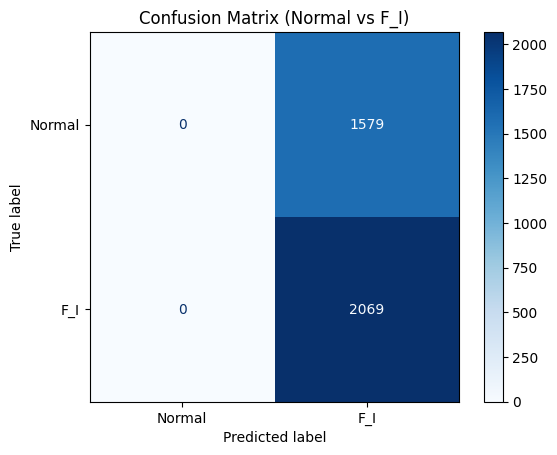

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = np.array([
    [TN, FP],
    [FN, TP]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "F_I"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Normal vs F_I)")
plt.show()

In [13]:
hasil = pd.DataFrame({
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "FPR": [fpr],
    "FNR": [fnr]
})

hasil

,Accuracy,Precision,Recall,F1-score,FPR,FNR
0,0.56716,0.56716,1.0,0.723806,1.0,0.0


In [14]:
# Ground truth sesuai label model
y_true = y_test.copy()
y_true[y_true == 1] = 3

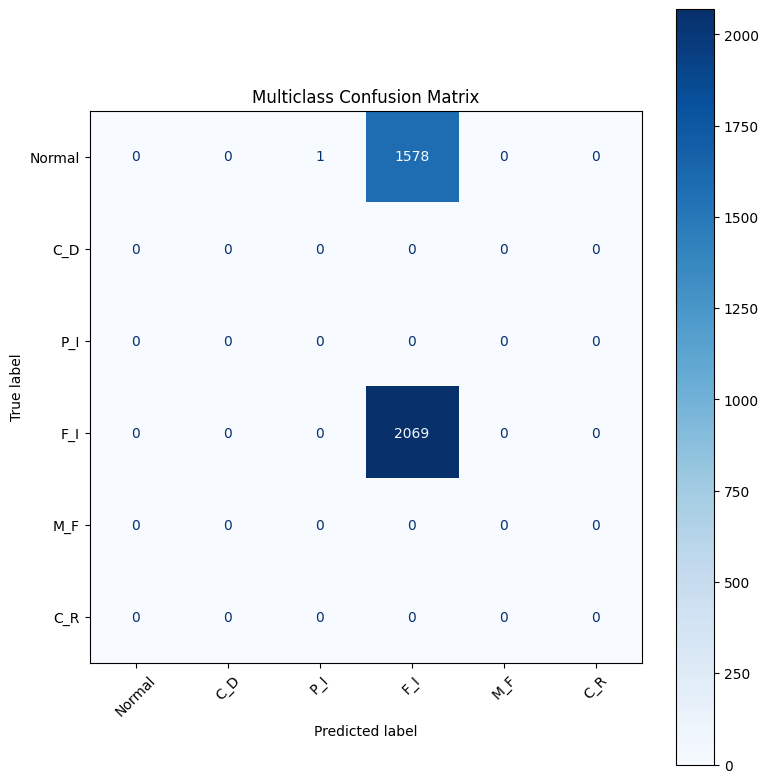

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = [0, 1, 2, 3, 4, 5]
class_names = ["Normal", "C_D", "P_I", "F_I", "M_F", "C_R"]

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=True)

plt.title("Multiclass Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()